# Exploring FRED Data

We download the latest FRED DJIA data from https://fred.stlouisfed.org/series/DJIA in CSV format and load it into Pandas.

## Fetching the data

In [76]:
URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=DJIA&scale=left&cosd=2019-01-01&coed=2026-03-23&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily%2C%20Close&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-03-24&revision_date=2026-03-24&nd=2016-03-24"

In [77]:
import pandas as pd

df = pd.read_csv(URL)

In [78]:
df

,observation_date,DJIA
0,2016-03-28,17535.39
1,2016-03-29,17633.11
2,2016-03-30,17716.66
3,2016-03-31,17685.09
4,2016-04-01,17792.75
...,...,...
2601,2026-03-17,46993.26
2602,2026-03-18,46225.15
2603,2026-03-19,46021.43
2604,2026-03-20,45577.47


## Analysis of data quality

In [4]:
number_of_nulls = df.isnull().sum().sum()
print("There are " + str(number_of_nulls) + " null values")

There are 69 null values


In [5]:
print("These are the columns with null values:")
df.isnull().sum()

These are the columns with null values:


,0
observation_date,0
DJIA,69


In [6]:
num_rows = len(df)
null_ratio = number_of_nulls / num_rows
# We can use fstrings in Python to format our strings

print(f"{null_ratio * 100:.2f} % of the data is null")

3.66 % of the data is null


## We can create a graph to visualize the data

[Text(0.5, 1.0, 'DJIA over time')]

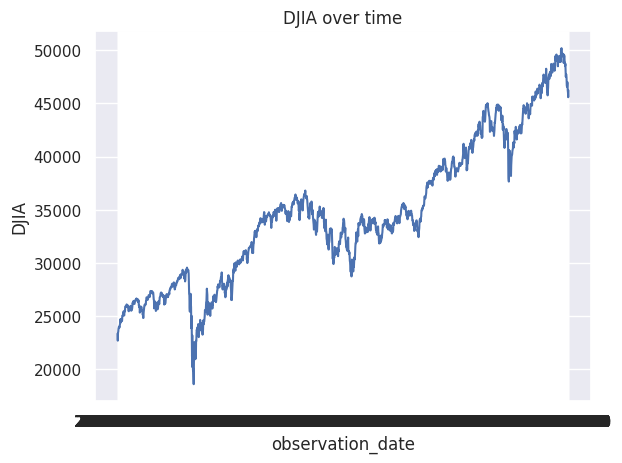

In [7]:
import seaborn as sns

sns.set_theme()

ax = sns.lineplot(df, x="observation_date", y="DJIA")
ax.set(
    title="DJIA over time"
)

In [8]:
df[df.DJIA.isnull()]

,observation_date,DJIA
13,2019-01-21,NaN
33,2019-02-18,NaN
77,2019-04-19,NaN
103,2019-05-27,NaN
131,2019-07-04,NaN
...,...,...
1801,2025-11-27,NaN
1821,2025-12-25,NaN
1826,2026-01-01,NaN
1838,2026-01-19,NaN


In [ ]:
df['DJIA'] = df['DJIA'].ffill()

In [ ]:
print(df['DJIA'].loc[1158])
print(df['DJIA'].loc[1159])
print(df['DJIA'].loc[1160])

# Cleaning the data

In [11]:
df[df['DJIA'].isnull()]

,observation_date,DJIA
13,2019-01-21,NaN
33,2019-02-18,NaN
77,2019-04-19,NaN
103,2019-05-27,NaN
131,2019-07-04,NaN
...,...,...
1801,2025-11-27,NaN
1821,2025-12-25,NaN
1826,2026-01-01,NaN
1838,2026-01-19,NaN


In [20]:
# We can Forward Fill our column DJIA by using the latest valid value
df["DJIA"] = df["DJIA"].ffill()

In [25]:
print(len(df))
print(len(df.dropna(axis=0, how='any')))
# We drop the rows that contain ANY NaN/null values
df = df.dropna(axis=0, how='any')
df

1884
1884


,observation_date,DJIA
0,2019-01-02,23346.24
1,2019-01-03,22686.22
2,2019-01-04,23433.16
3,2019-01-07,23531.35
4,2019-01-08,23787.45
...,...,...
1879,2026-03-17,46993.26
1880,2026-03-18,46225.15
1881,2026-03-19,46021.43
1882,2026-03-20,45577.47


# We can manipulate columns

In [ ]:
# We can create a new column
df["S&P"] = df["DJIA"] / 10

In [ ]:
# We can drop the new column using df.drop
df.drop(["S&P"], axis=1, inplace=True)
# Is strictly equivalent to
# df = df.drop(["S&P"], axis=1)

In [ ]:
df

# Creating the index

In [27]:
# By default, we have an index that represents the ORIGINAL row position
# We can access specific rows either by:

# 1. Using .iloc, which is the POSITION in the dataframe. Here, since the dataframe
# has 1256 rows, the last POSITION is 1255 (start counting at 0)
df.iloc[1255]

# 2. Using .loc, which is the NAME of the index in the dataframe. Here, the last row
# has the index value 1304
df.loc[1304]

,1304
observation_date,2024-01-02
DJIA,37715.04


In [30]:
# We can view the index of the DataFrame by using df.index
df.index
# We can cast it to a list if we need to
index_as_a_list = list(df.index)

In [31]:
# We want to set the column observation_date as the index.
# We can first check to see if it's unique (all the values in it are unique)
df["observation_date"].is_unique

True

In [45]:
# We can set the new index, since observation_date values are unique
df = df.set_index("observation_date")

# You can always undo this using
# df.reset_index() # Careful, this will start the new index from 0 and not remember dropped rows

In [35]:
# We can now use .loc[] to reference by date
df.loc["2024-03-22"]

# We can still use .iloc[] to refer by row number
df.iloc[0:100]

,DJIA
observation_date,
2019-01-02,23346.24
2019-01-03,22686.22
2019-01-04,23433.16
2019-01-07,23531.35
2019-01-08,23787.45
...,...
2019-05-15,25648.02
2019-05-16,25862.68
2019-05-17,25764.00


In [46]:
# We can see our new index
df.index

Index(['2019-01-02', '2019-01-03', '2019-01-04', '2019-01-07', '2019-01-08',
       '2019-01-09', '2019-01-10', '2019-01-11', '2019-01-14', '2019-01-15',
       ...
       '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-16',
       '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20', '2026-03-23'],
      dtype='object', name='observation_date', length=1884)

In [37]:
# We can view our columns. Notice observation_date is gone, because
# it is now the index
df.columns

Index(['DJIA'], dtype='object')

In [47]:
# We can convert our index from a type string to a type datetime
df.index = pd.to_datetime(df.index)

In [48]:
df.index

DatetimeIndex(['2019-01-02', '2019-01-03', '2019-01-04', '2019-01-07',
               '2019-01-08', '2019-01-09', '2019-01-10', '2019-01-11',
               '2019-01-14', '2019-01-15',
               ...
               '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13',
               '2026-03-16', '2026-03-17', '2026-03-18', '2026-03-19',
               '2026-03-20', '2026-03-23'],
              dtype='datetime64[ns]', name='observation_date', length=1884, freq=None)

In [49]:
df.loc["2023":"2025"]

,DJIA
observation_date,
2023-01-02,33147.25
2023-01-03,33136.37
2023-01-04,33269.77
2023-01-05,32930.08
2023-01-06,33630.61
...,...
2025-12-25,48731.16
2025-12-26,48710.97
2025-12-29,48461.93


In [50]:
# Now that we have DateTimeIndex, we can do some easy date filtering
# For example, we can filter our dataframe for a given year
df.loc["2026"]
# Or we can use datetime attributes to filter using our index
df[df.index.day_of_week == 4]

,DJIA
observation_date,
2019-01-04,23433.16
2019-01-11,23995.95
2019-01-18,24706.35
2019-01-25,24737.20
2019-02-01,25063.89
...,...
2026-02-20,49625.97
2026-02-27,48977.92
2026-03-06,47501.55


<Axes: xlabel='observation_date', ylabel='DJIA'>

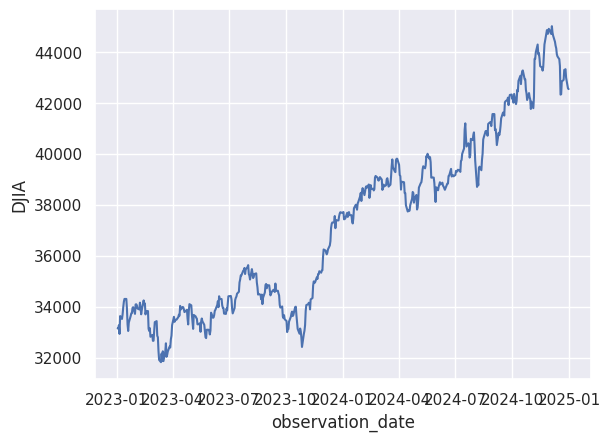

In [53]:
sns.lineplot(df.loc["2023":"2024"], x=df.loc["2023":"2024"].index, y="DJIA")

# Let's analyze DJIA returns

In [55]:
df.DJIA.pct_change

<bound method NDFrame.pct_change of observation_date
2019-01-02    23346.24
2019-01-03    22686.22
2019-01-04    23433.16
2019-01-07    23531.35
2019-01-08    23787.45
                ...   
2026-03-17    46993.26
2026-03-18    46225.15
2026-03-19    46021.43
2026-03-20    45577.47
2026-03-23    46208.47
Name: DJIA, Length: 1884, dtype: float64>

In [59]:
# Let's calculate the daily_returns, in percentage, and store it in the "returns" column
df['daily_returns'] = df.DJIA.pct_change()

In [64]:
# We can get the average return of the DJIA
df['daily_returns'].mean()

np.float64(0.00043269574413951485)

In [65]:
# We can get the highest and lowest returns of the DJIA
df['daily_returns'].describe()

,daily_returns
count,1883.000000
mean,0.000433
std,0.011812
min,-0.129265
25%,-0.004242
50%,0.000386
75%,0.005675
max,0.113650


<Axes: xlabel='observation_date'>

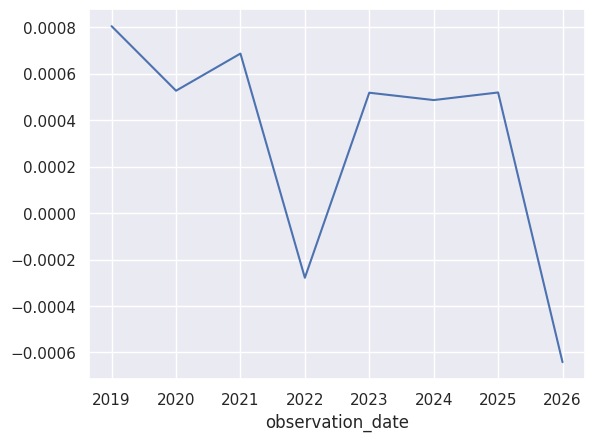

In [68]:
# We can take a look at average returns by year
df.groupby(df.index.year)['daily_returns'].mean().plot(kind='line')

<Axes: xlabel='observation_date', ylabel='daily_returns'>

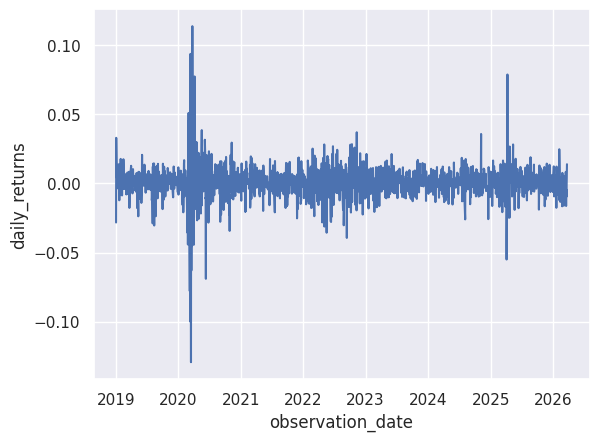

In [70]:
sns.lineplot(df, x=df.index, y="daily_returns")

<Axes: xlabel='daily_returns', ylabel='Count'>

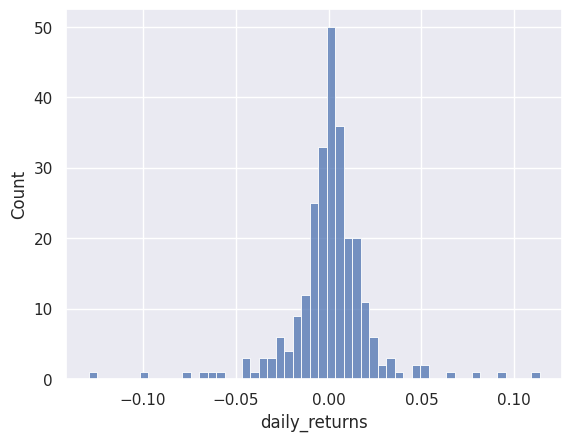

In [75]:
sns.histplot(df.loc["2020"], x='daily_returns')